# 03 — Adstock & Saturation Transform Library

> **Objective**: Build, visualise, and validate the full adstock and saturation transformation library on real Indian FMCG data (156 national weekly observations, 6 media channels).

**Key Topics**:
- Geometric adstock — impulse response, half-life reference table
- Weibull adstock — delayed-peak effect, shape vs. geometric comparison
- Hill, Logistic, and Negative Exponential saturation functions
- Full transform pipeline: Raw Impressions → Adstock → Saturation (all 6 channels)
- Parameter sensitivity analysis: decay × K heatmap

**Data**: `synthetic_mmm_weekly_india.csv` — national weekly aggregate, Jul 2022 – Jun 2025  
**Framework**: Python — `numpy`, `scipy`, `matplotlib`, `seaborn`  
**Informed by NB01 & NB02**: TV dominates (42.8% impressions, HL ≈ 1.9 weeks); Instagram collinear with YouTube (r = 0.96); Constrained Ridge R² = 0.81

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import fftconvolve
from scipy.stats import weibull_min
import os
import sys

# ─── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('colorblind')

OUTPUT_DIR = '../outputs/figures'
DATA_PATH  = '../data/raw/synthetic_mmm_weekly_india.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries loaded ✓")
print(f"Output dir : {os.path.abspath(OUTPUT_DIR)}")
print(f"Data path  : {os.path.abspath(DATA_PATH)}")

Libraries loaded ✓
Output dir : C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\marketing-mix-modelling\marketing-mix-modelling\outputs\figures
Data path  : C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\marketing-mix-modelling\marketing-mix-modelling\data\raw\synthetic_mmm_weekly_india.csv


## 1. Geometric Adstock — Impulse Response

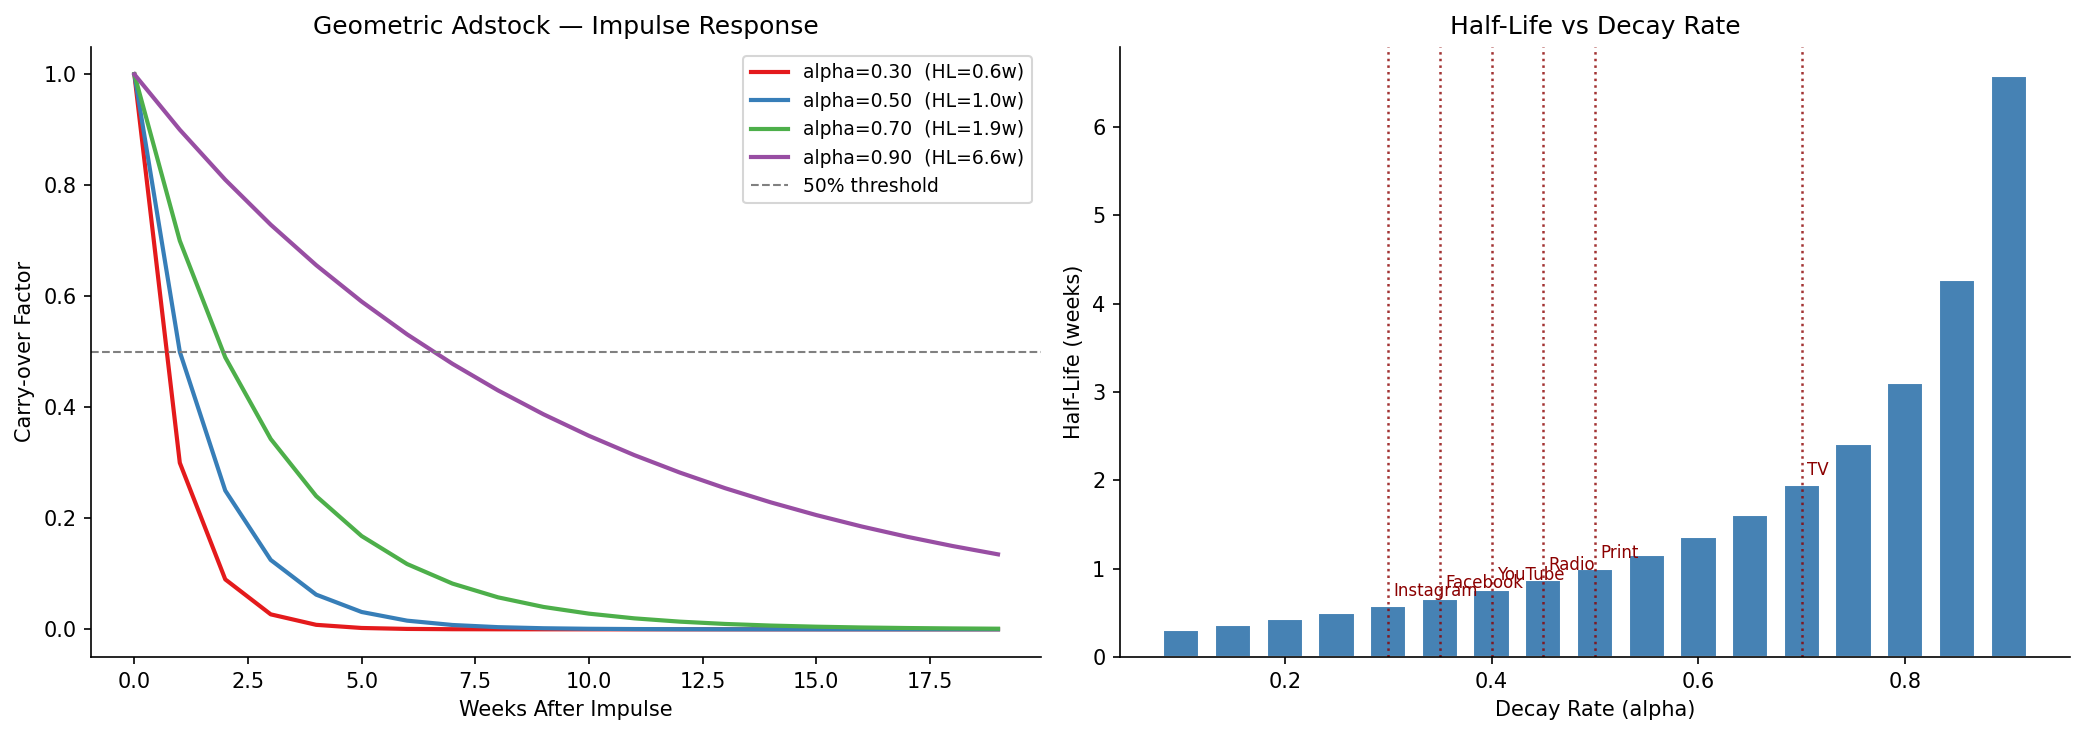


Channel Half-Life Reference Table
  Channel        decay   HL (wk)    1% @ wk
  ------------------------------------------------
  TV              0.70       1.9         13
  Print           0.50       1.0          7
  YouTube         0.40       0.8          6
  Radio           0.45       0.9          6
  Facebook        0.35       0.7          5
  Instagram       0.30       0.6          4


In [2]:
# ─── Geometric Adstock Implementation ────────────────────────────────────────

def geometric_adstock(x, decay, normalise=True):
    """Geometric (Koyck) adstock.

    Each period the stock decays by `decay` and accumulates the current input:
        stock[t] = x[t] + decay * stock[t-1]

    Parameters
    ----------
    x         : 1-D array of impressions / spend
    decay     : carryover factor in (0, 1)
    normalise : divide by peak so output stays in [0, 1]
    """
    x  = np.asarray(x, dtype=float)
    n  = len(x)
    out = np.empty(n)
    out[0] = x[0]
    for t in range(1, n):
        out[t] = x[t] + decay * out[t - 1]
    if normalise and out.max() > 0:
        out /= out.max()
    return out


def half_life(alpha):
    """Number of weeks for the in-flight adstock effect to halve."""
    return np.log(0.5) / np.log(alpha)


# ─── Unit Impulse Response ────────────────────────────────────────────────────
impulse     = np.zeros(20)
impulse[0]  = 1.0
decay_rates = [0.30, 0.50, 0.70, 0.90]
colors      = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha, col in zip(decay_rates, colors):
    resp = geometric_adstock(impulse, alpha, normalise=False)
    hl   = half_life(alpha)
    axes[0].plot(resp, color=col, lw=2, label=f'alpha={alpha:.2f}  (HL={hl:.1f}w)')

axes[0].axhline(0.5, color='grey', ls='--', lw=1, label='50% threshold')
axes[0].set_title('Geometric Adstock — Impulse Response', fontsize=12)
axes[0].set_xlabel('Weeks After Impulse')
axes[0].set_ylabel('Carry-over Factor')
axes[0].legend(fontsize=9)

# ─── Half-Life Bar Chart ──────────────────────────────────────────────────────
decay_range = np.round(np.arange(0.10, 0.95, 0.05), 2)
hl_values   = [half_life(d) for d in decay_range]

axes[1].bar(decay_range, hl_values, width=0.035, color='steelblue', edgecolor='white')
axes[1].set_title('Half-Life vs Decay Rate', fontsize=12)
axes[1].set_xlabel('Decay Rate (alpha)')
axes[1].set_ylabel('Half-Life (weeks)')

channel_decays = {
    'TV': 0.70, 'Print': 0.50, 'YouTube': 0.40,
    'Radio': 0.45, 'Facebook': 0.35, 'Instagram': 0.30,
}
for ch_name, ch_alpha in channel_decays.items():
    hl_ch = half_life(ch_alpha)
    axes[1].axvline(ch_alpha, color='darkred', ls=':', lw=1.2, alpha=0.8)
    axes[1].text(ch_alpha + 0.005, hl_ch + 0.12, ch_name, fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_geometric_adstock_impulse.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── Half-Life Reference Table ────────────────────────────────────────────────
print("\nChannel Half-Life Reference Table")
print("=" * 52)
print(f"  {'Channel':<13} {'decay':>6} {'HL (wk)':>9} {'1% @ wk':>10}")
print("  " + "-" * 48)
for ch, alpha in channel_decays.items():
    hl      = half_life(alpha)
    wk_1pct = int(np.ceil(np.log(0.01) / np.log(alpha)))
    print(f"  {ch:<13} {alpha:>6.2f} {hl:>9.1f} {wk_1pct:>10d}")

## 2. Weibull Adstock — Delayed Peak Effect

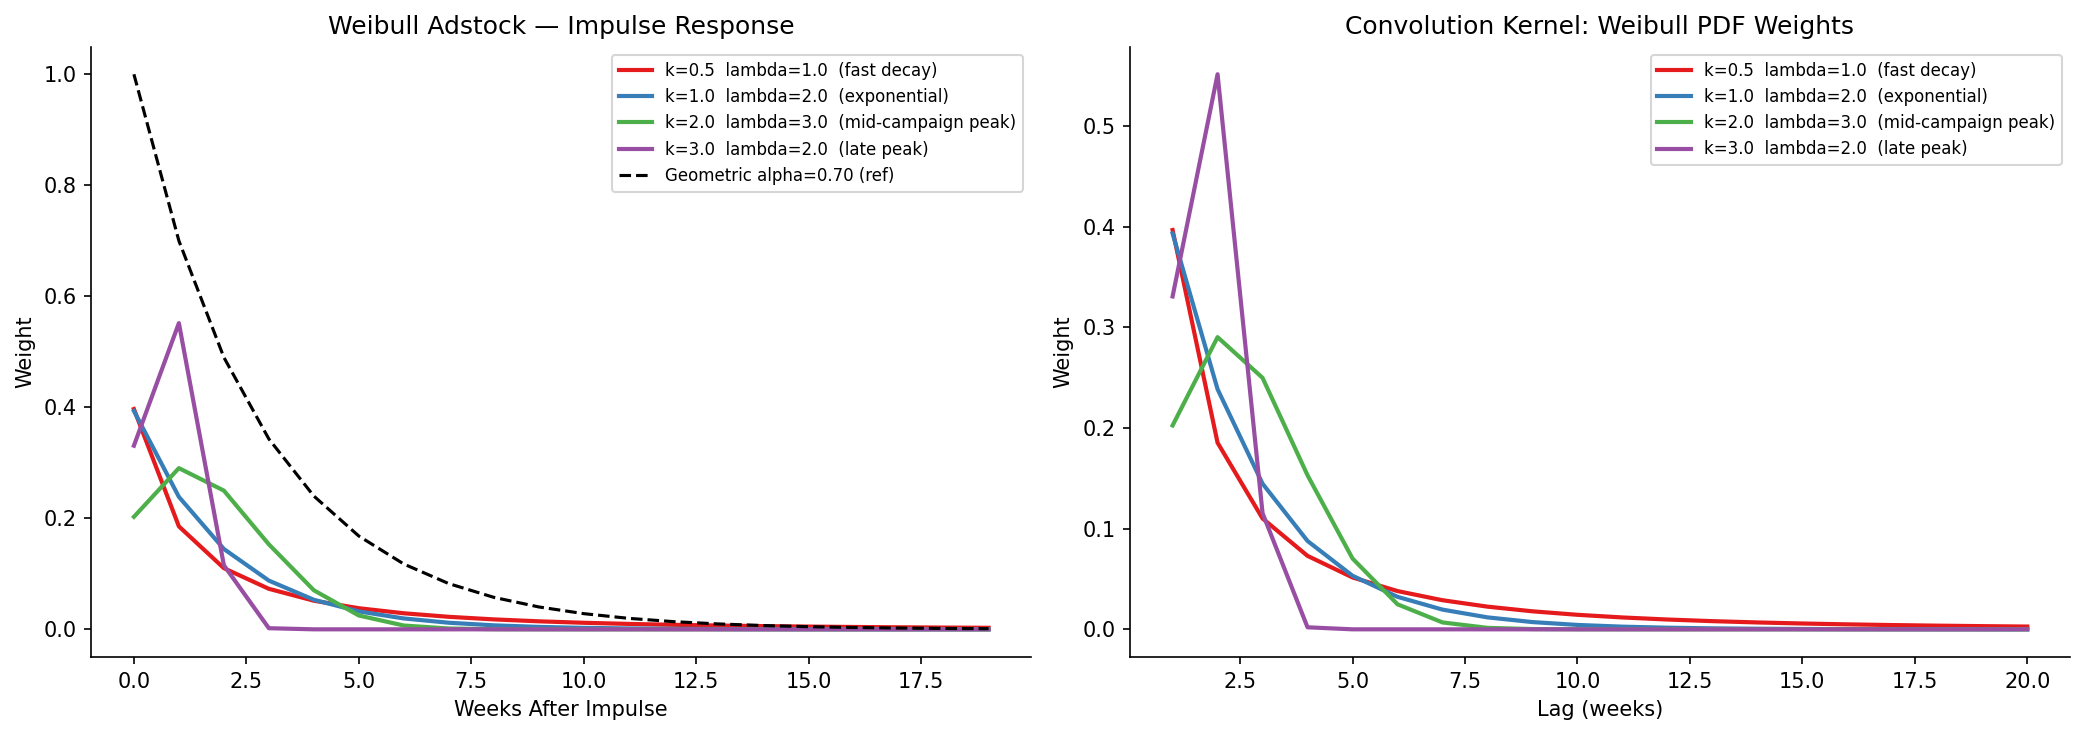

Weibull adstock implemented.

Key insight: k < 1 -> fast initial decay (similar to geometric)
             k = 1 -> mathematically equivalent to geometric
             k > 1 -> delayed peak (TV brand awareness build-up)


In [3]:
# ─── Weibull Adstock Implementation ──────────────────────────────────────────

def weibull_adstock(x, shape=1.0, scale=2.0, maxlag=20, normalise=True):
    """Weibull-distributed lag adstock via FFT convolution.

    Parameters
    ----------
    x        : 1-D array
    shape    : Weibull shape k  (k < 1 → fast decay; k > 1 → delayed peak)
    scale    : Weibull scale lambda
    maxlag   : truncation window (weeks)
    normalise: scale output to [0, 1]
    """
    x       = np.asarray(x, dtype=float)
    lags    = np.arange(1, maxlag + 1, dtype=float)
    weights = weibull_min.pdf(lags, c=shape, scale=scale)
    weights /= weights.sum()                              # normalise PDF
    result  = fftconvolve(x, weights, mode='full')[:len(x)]
    if normalise and result.max() > 0:
        result /= result.max()
    return result


# ─── Impulse Responses ───────────────────────────────────────────────────────
params_weibull = [
    (0.5, 1.0, 'k=0.5  lambda=1.0  (fast decay)'),
    (1.0, 2.0, 'k=1.0  lambda=2.0  (exponential)'),
    (2.0, 3.0, 'k=2.0  lambda=3.0  (mid-campaign peak)'),
    (3.0, 2.0, 'k=3.0  lambda=2.0  (late peak)'),
]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (shape, scale, label), col in zip(params_weibull, colors):
    resp = weibull_adstock(impulse, shape, scale, normalise=False)
    axes[0].plot(resp, color=col, lw=2, label=label)

# Geometric alpha=0.70 as reference
geo_ref = geometric_adstock(impulse, 0.70, normalise=False)
axes[0].plot(geo_ref, '--k', lw=1.5, label='Geometric alpha=0.70 (ref)')
axes[0].set_title('Weibull Adstock — Impulse Response', fontsize=12)
axes[0].set_xlabel('Weeks After Impulse')
axes[0].set_ylabel('Weight')
axes[0].legend(fontsize=8)

# ─── PDF Kernel Weights ───────────────────────────────────────────────────────
lags_arr = np.arange(1, 21, dtype=float)
for (shape, scale, label), col in zip(params_weibull, colors):
    wts = weibull_min.pdf(lags_arr, c=shape, scale=scale)
    wts /= wts.sum()
    axes[1].plot(lags_arr, wts, color=col, lw=2, label=label)

axes[1].set_title('Convolution Kernel: Weibull PDF Weights', fontsize=12)
axes[1].set_xlabel('Lag (weeks)')
axes[1].set_ylabel('Weight')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_weibull_adstock.png', bbox_inches='tight', dpi=150)
plt.show()

print("Weibull adstock implemented.")
print()
print("Key insight: k < 1 -> fast initial decay (similar to geometric)")
print("             k = 1 -> mathematically equivalent to geometric")
print("             k > 1 -> delayed peak (TV brand awareness build-up)")

## 3. Geometric vs. Weibull Comparison

National weekly data: 156 weeks
Date range          : 2022-07-04 -> 2025-06-23



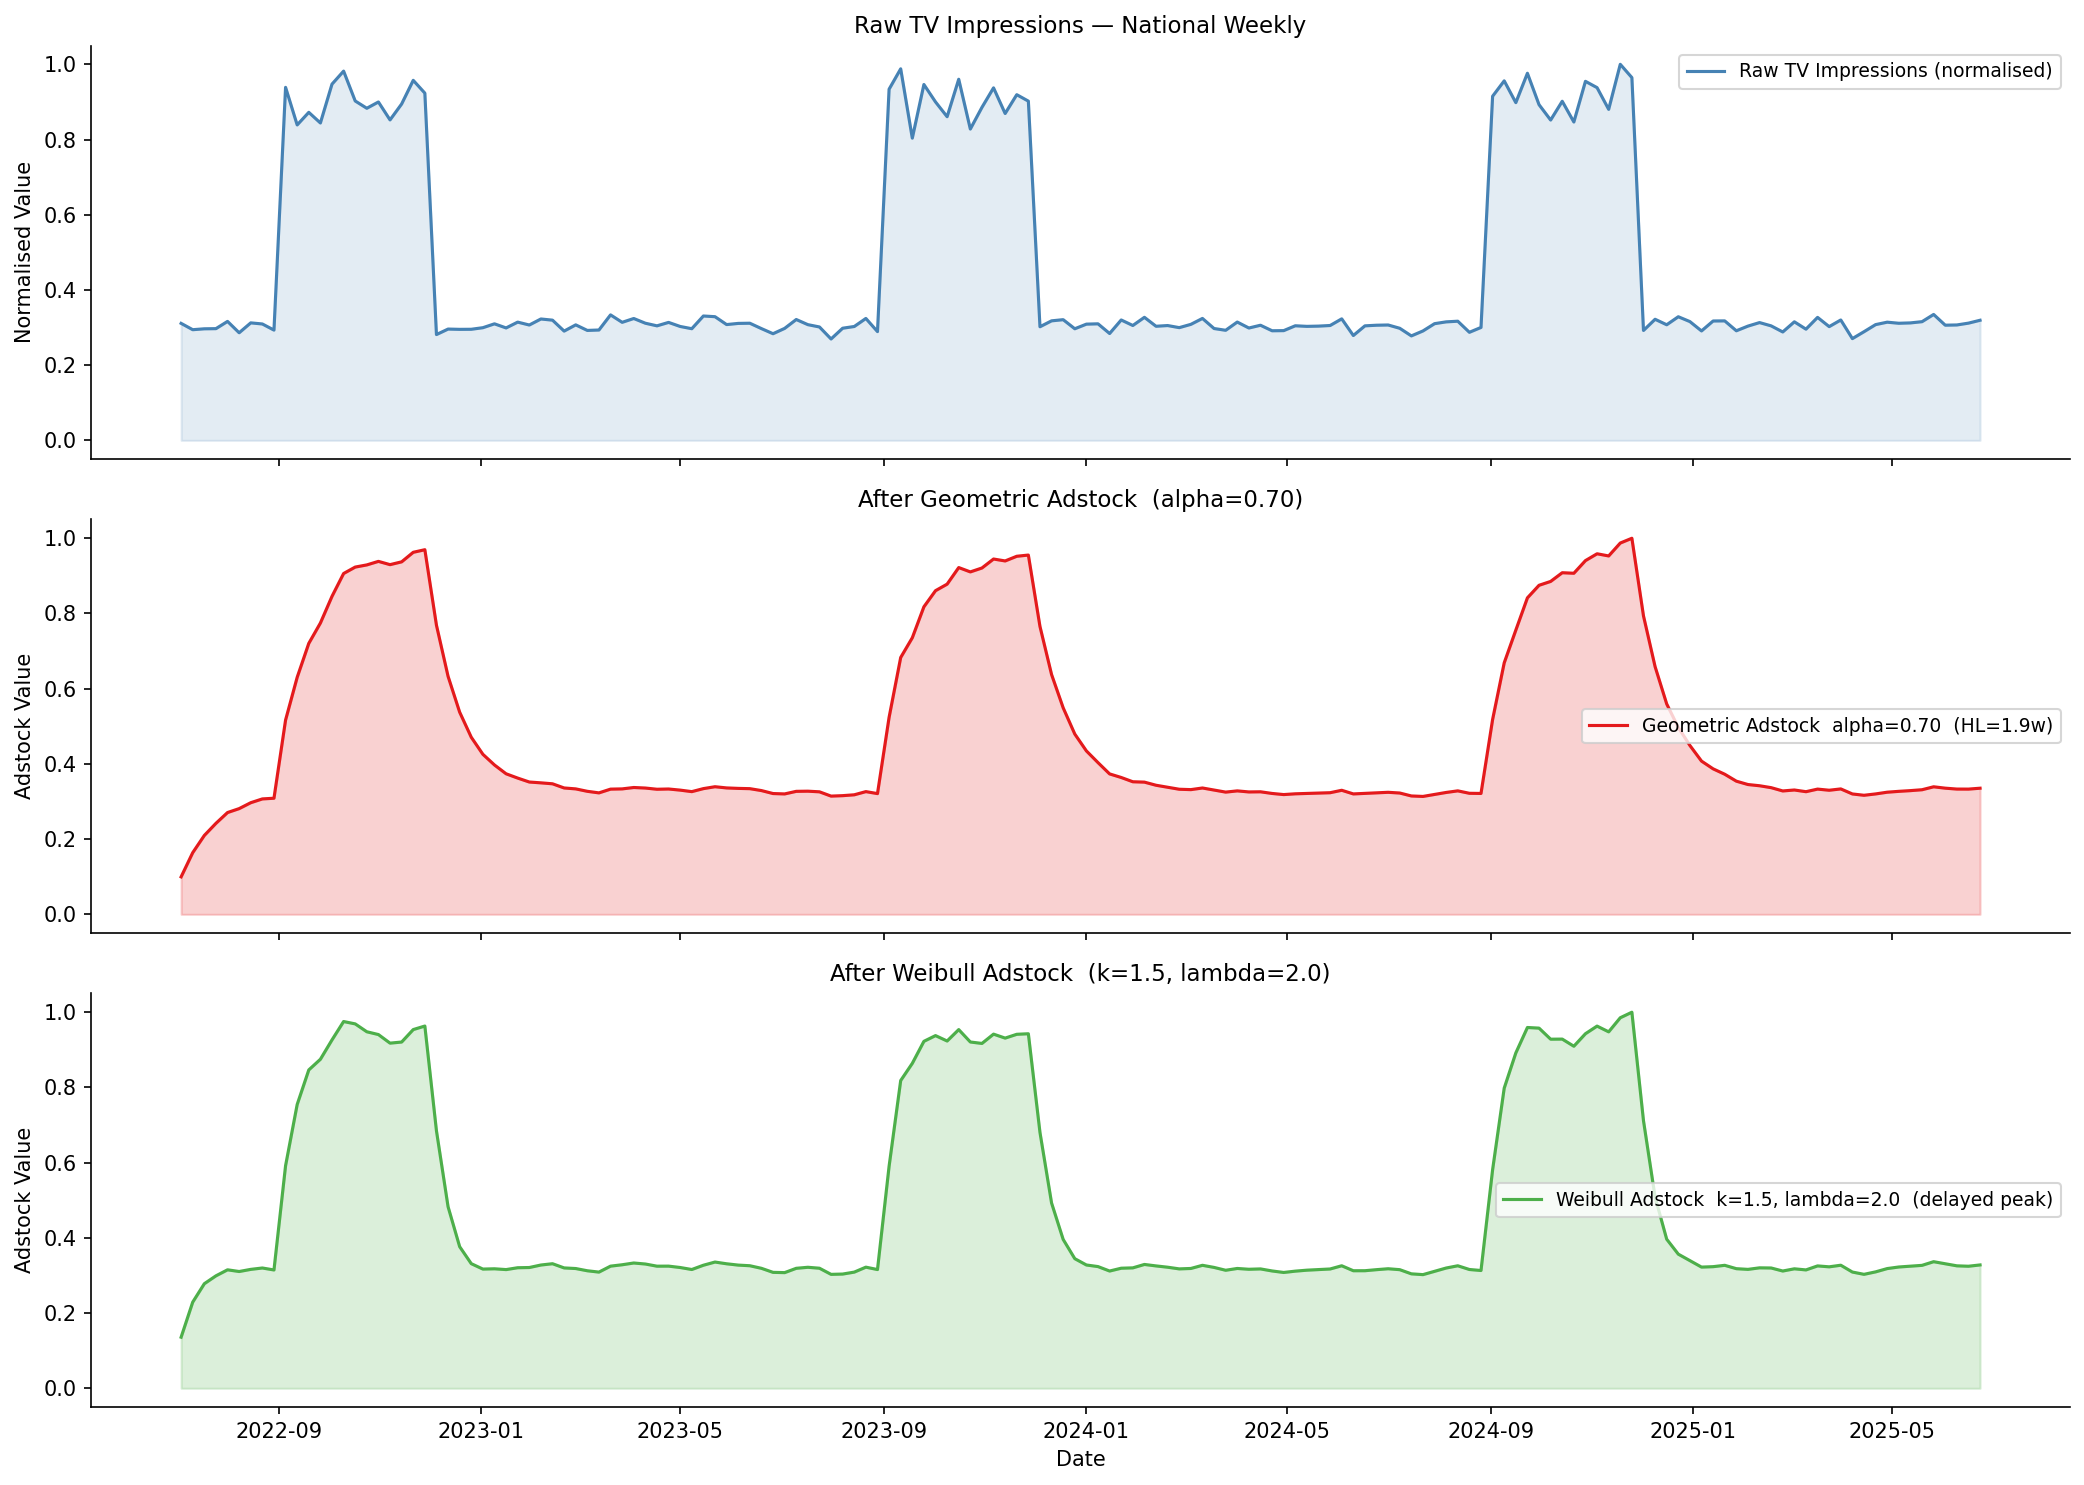

Pearson correlation  (Geometric vs Weibull) : 0.9764
Mean absolute diff   (% of geometric mean) : 7.48%

Both transforms are highly correlated on real weekly data.
Weibull adds flexibility for delayed-peak (brand awareness) TV campaigns.
For classical MMM, geometric is preferred for parsimony and interpretability.


In [4]:
# ─── Load real national weekly TV data ───────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df.rename(columns={'Week': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

media_cols = [
    'TV_Impressions', 'YouTube_Impressions', 'Facebook_Impressions',
    'Instagram_Impressions', 'Print_Readership', 'Radio_Listenership',
]

# Media columns are at geo level — deduplicate by (date, Geo) then sum to national
media_natl = (
    df.groupby(['date', 'Geo'])[media_cols].first()
      .groupby('date').sum()
)

print(f"National weekly data: {len(media_natl)} weeks")
print(f"Date range          : {media_natl.index.min().date()} -> {media_natl.index.max().date()}")
print()

tv_vals = media_natl['TV_Impressions'].values.astype(float)
tv_norm = tv_vals / tv_vals.max()
weeks   = media_natl.index

# ─── Apply both adstock transforms ───────────────────────────────────────────
geo_tv = geometric_adstock(tv_norm, decay=0.70, normalise=True)
wb_tv  = weibull_adstock(tv_norm,  shape=1.5, scale=2.0, normalise=True)

# ─── 3-panel comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weeks, tv_norm, color='steelblue', lw=1.5, label='Raw TV Impressions (normalised)')
axes[0].fill_between(weeks, 0, tv_norm, alpha=0.15, color='steelblue')
axes[0].set_title('Raw TV Impressions — National Weekly', fontsize=11)
axes[0].set_ylabel('Normalised Value')
axes[0].legend(fontsize=9)

axes[1].plot(weeks, geo_tv, color='#e41a1c', lw=1.5,
             label='Geometric Adstock  alpha=0.70  (HL=1.9w)')
axes[1].fill_between(weeks, 0, geo_tv, alpha=0.20, color='#e41a1c')
axes[1].set_title('After Geometric Adstock  (alpha=0.70)', fontsize=11)
axes[1].set_ylabel('Adstock Value')
axes[1].legend(fontsize=9)

axes[2].plot(weeks, wb_tv, color='#4daf4a', lw=1.5,
             label='Weibull Adstock  k=1.5, lambda=2.0  (delayed peak)')
axes[2].fill_between(weeks, 0, wb_tv, alpha=0.20, color='#4daf4a')
axes[2].set_title('After Weibull Adstock  (k=1.5, lambda=2.0)', fontsize=11)
axes[2].set_ylabel('Adstock Value')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_geo_vs_weibull_tv.png', bbox_inches='tight', dpi=150)
plt.show()

corr    = np.corrcoef(geo_tv, wb_tv)[0, 1]
mae_pct = np.mean(np.abs(geo_tv - wb_tv)) / (np.mean(geo_tv) + 1e-10) * 100
print(f"Pearson correlation  (Geometric vs Weibull) : {corr:.4f}")
print(f"Mean absolute diff   (% of geometric mean) : {mae_pct:.2f}%")
print()
print("Both transforms are highly correlated on real weekly data.")
print("Weibull adds flexibility for delayed-peak (brand awareness) TV campaigns.")
print("For classical MMM, geometric is preferred for parsimony and interpretability.")

## 4. Hill Saturation Function

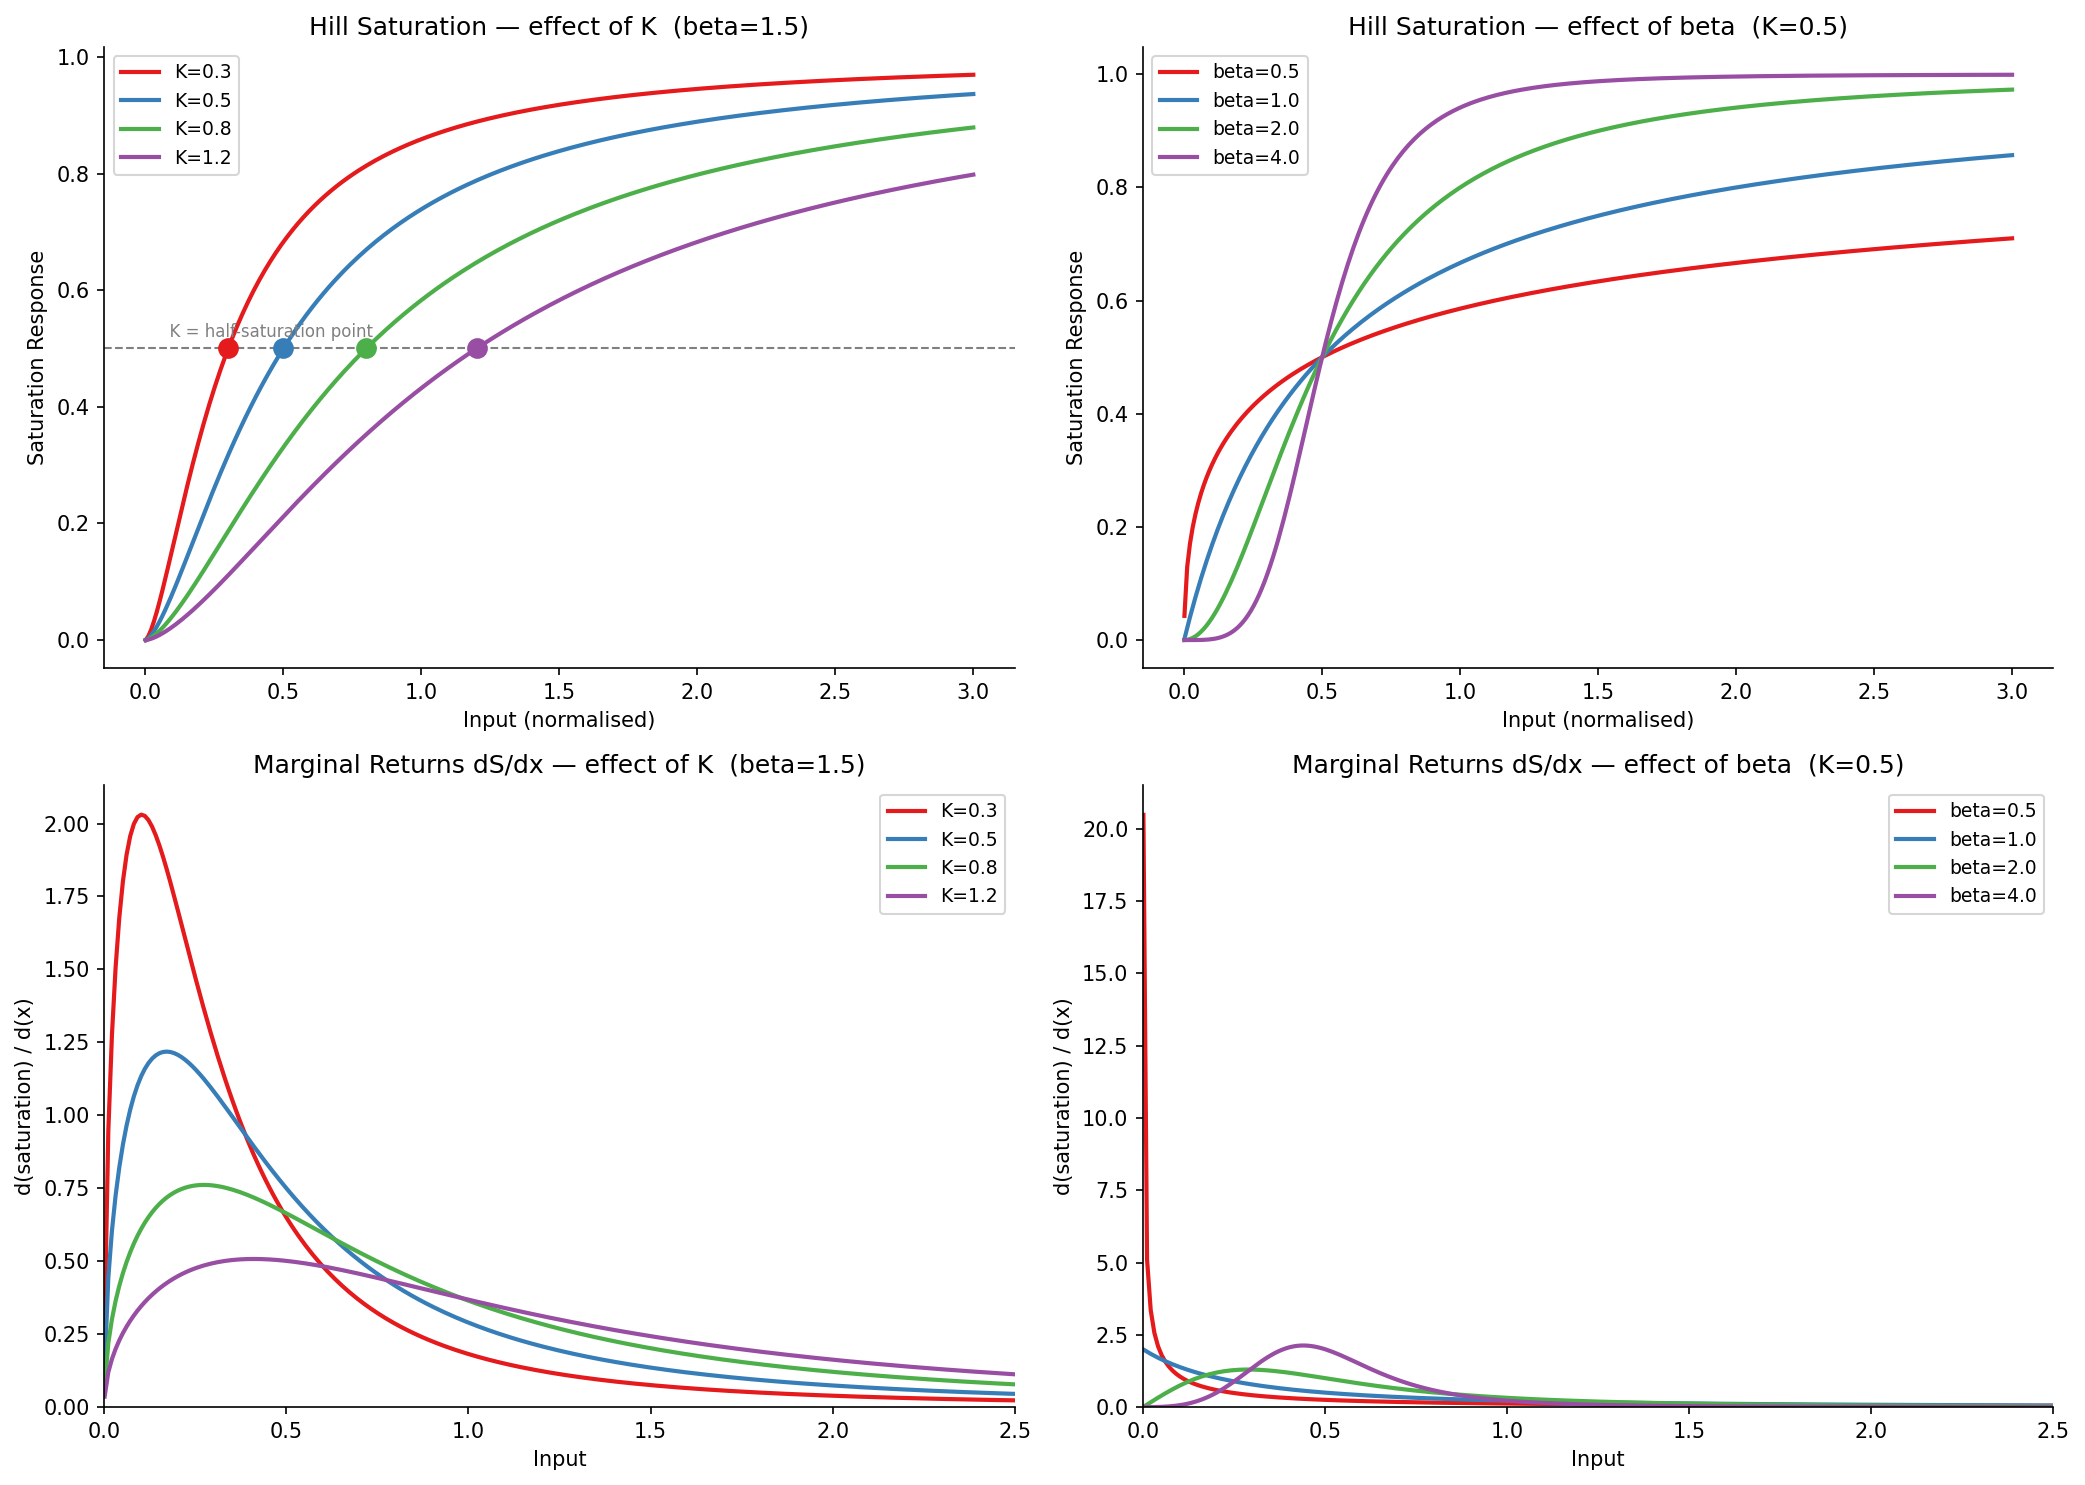

Key Hill parameter interpretation:
  K  = half-saturation constant (spend at which 50% saturation is reached)
  beta < 1 : concave-only — pure diminishing returns, no S-curve inflection
  beta = 1 : Michaelis-Menten (gentle S, most common for FMCG TV)
  beta > 1 : steeper inflection — threshold / awareness-build effect


In [5]:
# ─── Hill Saturation Implementation ──────────────────────────────────────────

def hill_saturation(x, K=0.5, beta=1.0):
    """Hill / power-law saturation:  f(x) = x^beta / (K^beta + x^beta)

    Parameters
    ----------
    x    : input (non-negative)
    K    : half-saturation constant — f(K) = 0.5
    beta : Hill coefficient (steepness)
           beta < 1 : concave only (diminishing returns, no inflection)
           beta = 1 : Michaelis-Menten (gentle S-shape)
           beta > 1 : steeper S-curve (threshold / awareness build)
    """
    x = np.asarray(x, dtype=float)
    return x**beta / (K**beta + x**beta)


def marginal_hill(x, K=0.5, beta=1.0):
    """Analytic first derivative of Hill function dS/dx."""
    x   = np.asarray(x, dtype=float) + 1e-12
    num = beta * K**beta * x**(beta - 1)
    den = (K**beta + x**beta)**2
    return num / den


x_plot    = np.linspace(0.001, 3.0, 300)
K_vals    = [0.30, 0.50, 0.80, 1.20]
beta_vals = [0.50, 1.00, 2.00, 4.00]
colors    = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ─── Top-left: vary K (beta fixed = 1.5) ─────────────────────────────────────
for K, col in zip(K_vals, colors):
    axes[0, 0].plot(x_plot, hill_saturation(x_plot, K=K, beta=1.5),
                    color=col, lw=2, label=f'K={K}')
    axes[0, 0].scatter([K], [0.5], color=col, s=80, zorder=5)
axes[0, 0].axhline(0.5, color='grey', ls='--', lw=1)
axes[0, 0].set_title('Hill Saturation — effect of K  (beta=1.5)', fontsize=12)
axes[0, 0].set_xlabel('Input (normalised)')
axes[0, 0].set_ylabel('Saturation Response')
axes[0, 0].legend(fontsize=9)
axes[0, 0].text(0.05, 0.52, '  K = half-saturation point', fontsize=8, color='grey')

# ─── Top-right: vary beta (K fixed = 0.5) ────────────────────────────────────
for beta, col in zip(beta_vals, colors):
    axes[0, 1].plot(x_plot, hill_saturation(x_plot, K=0.5, beta=beta),
                    color=col, lw=2, label=f'beta={beta}')
axes[0, 1].set_title('Hill Saturation — effect of beta  (K=0.5)', fontsize=12)
axes[0, 1].set_xlabel('Input (normalised)')
axes[0, 1].set_ylabel('Saturation Response')
axes[0, 1].legend(fontsize=9)

# ─── Bottom-left: marginal returns — vary K ───────────────────────────────────
for K, col in zip(K_vals, colors):
    axes[1, 0].plot(x_plot, marginal_hill(x_plot, K=K, beta=1.5),
                    color=col, lw=2, label=f'K={K}')
axes[1, 0].set_xlim(0, 2.5)
axes[1, 0].set_ylim(bottom=0)
axes[1, 0].set_title('Marginal Returns dS/dx — effect of K  (beta=1.5)', fontsize=12)
axes[1, 0].set_xlabel('Input')
axes[1, 0].set_ylabel('d(saturation) / d(x)')
axes[1, 0].legend(fontsize=9)

# ─── Bottom-right: marginal returns — vary beta ──────────────────────────────
for beta, col in zip(beta_vals, colors):
    axes[1, 1].plot(x_plot, marginal_hill(x_plot, K=0.5, beta=beta),
                    color=col, lw=2, label=f'beta={beta}')
axes[1, 1].set_xlim(0, 2.5)
axes[1, 1].set_ylim(bottom=0)
axes[1, 1].set_title('Marginal Returns dS/dx — effect of beta  (K=0.5)', fontsize=12)
axes[1, 1].set_xlabel('Input')
axes[1, 1].set_ylabel('d(saturation) / d(x)')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_hill_saturation.png', bbox_inches='tight', dpi=150)
plt.show()

print("Key Hill parameter interpretation:")
print("  K  = half-saturation constant (spend at which 50% saturation is reached)")
print("  beta < 1 : concave-only — pure diminishing returns, no S-curve inflection")
print("  beta = 1 : Michaelis-Menten (gentle S, most common for FMCG TV)")
print("  beta > 1 : steeper inflection — threshold / awareness-build effect")

## 5. Logistic & Negative Exponential Saturation

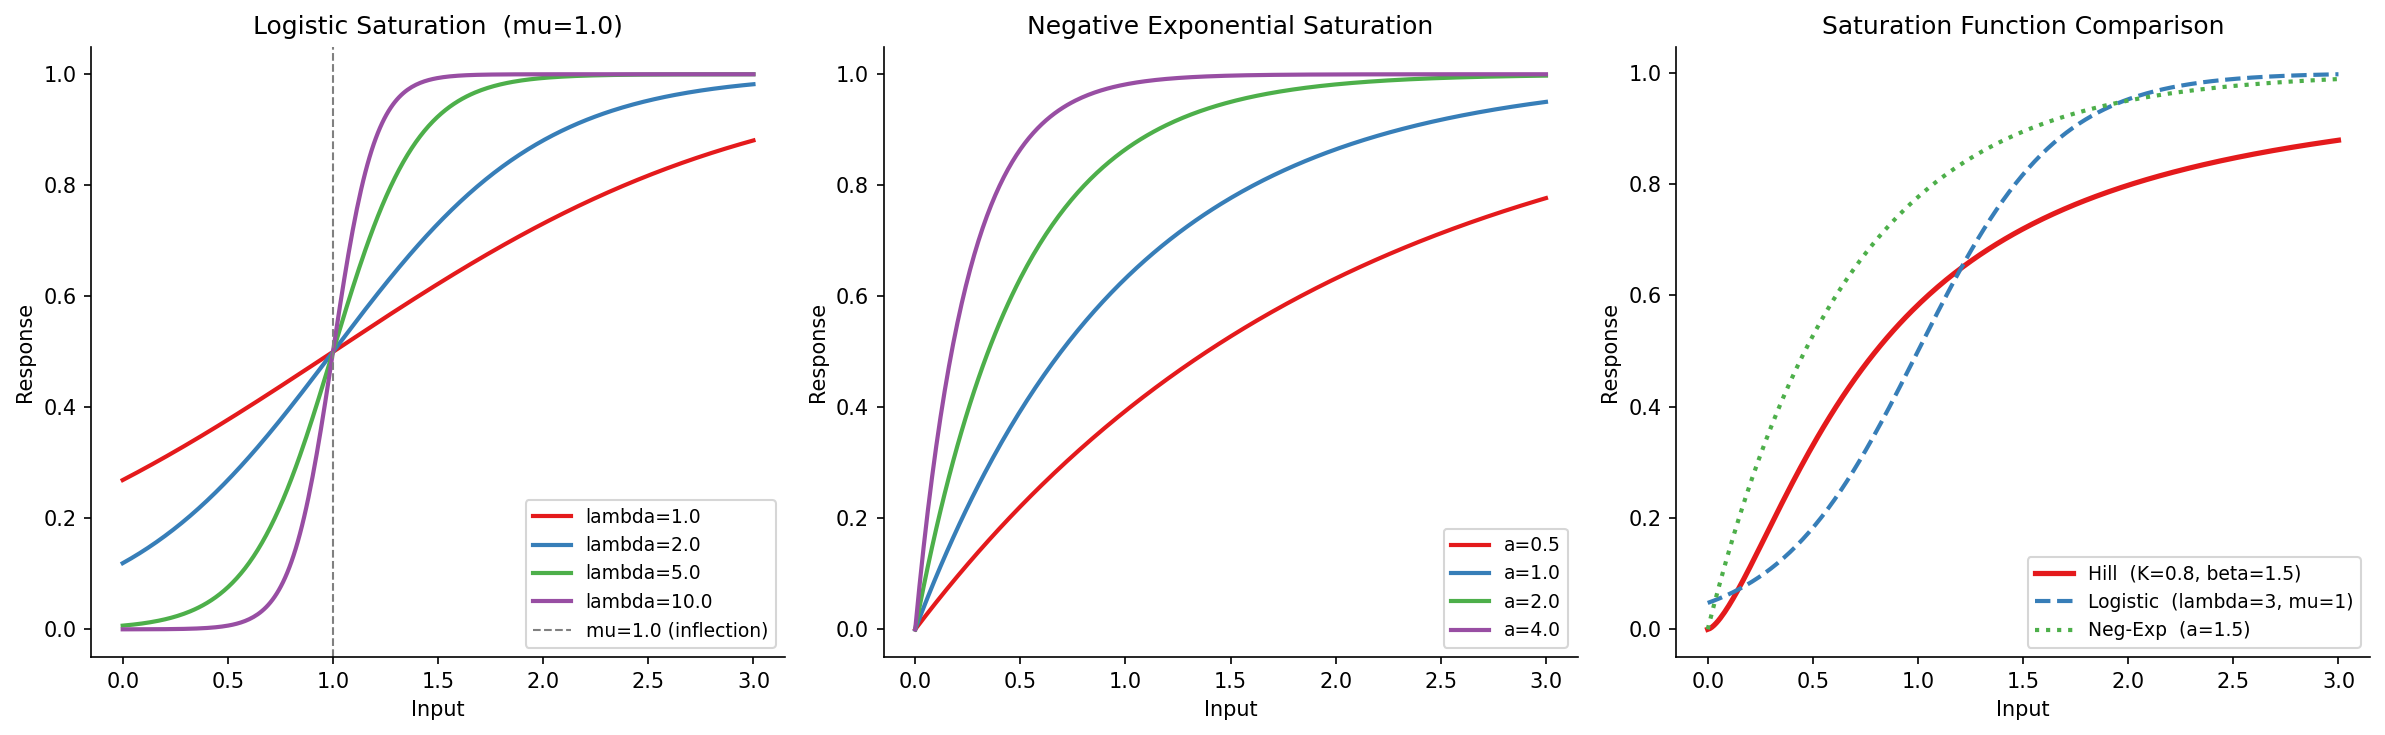

Saturation Function Characteristics
-----------------------------------------------------------------
Hill       : Flexible S-curve — K and beta directly interpretable.
             Industry standard for MMM (PyMC-Marketing & Meridian).
Logistic   : Symmetric S-curve centred at mu.
             Assumes increasing-then-decreasing marginal returns.
Neg-Exp    : Purely concave. Never reaches plateau at finite spend.
             Best for high-frequency digital performance channels.

CHOICE FOR THIS PROJECT: Hill saturation (K, beta) — most flexible


In [6]:
# ─── Logistic Saturation ──────────────────────────────────────────────────────

def logistic_saturation(x, lam=1.0, mu=1.0):
    """Symmetric logistic S-curve:  f(x) = 1 / (1 + exp(-lambda * (x - mu)))

    lam : steepness;  mu : inflection point (half-saturation)
    """
    return 1.0 / (1.0 + np.exp(-lam * (np.asarray(x, dtype=float) - mu)))


def neg_exp_saturation(x, a=2.0):
    """Negative exponential:  f(x) = 1 - exp(-a * x)

    Purely concave (no S-curve); fast-saturating channels (tactical digital).
    """
    return 1.0 - np.exp(-a * np.asarray(x, dtype=float))


x_plot = np.linspace(0, 3.0, 300)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ─── Logistic ─────────────────────────────────────────────────────────────────
lam_vals = [1.0, 2.0, 5.0, 10.0]
for lam, col in zip(lam_vals, colors):
    axes[0].plot(x_plot, logistic_saturation(x_plot, lam=lam, mu=1.0),
                 color=col, lw=2, label=f'lambda={lam}')
axes[0].axvline(1.0, color='grey', ls='--', lw=1, label='mu=1.0 (inflection)')
axes[0].set_title('Logistic Saturation  (mu=1.0)', fontsize=12)
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Response')
axes[0].legend(fontsize=9)

# ─── Negative Exponential ────────────────────────────────────────────────────
a_vals = [0.5, 1.0, 2.0, 4.0]
for a, col in zip(a_vals, colors):
    axes[1].plot(x_plot, neg_exp_saturation(x_plot, a=a),
                 color=col, lw=2, label=f'a={a}')
axes[1].set_title('Negative Exponential Saturation', fontsize=12)
axes[1].set_xlabel('Input')
axes[1].set_ylabel('Response')
axes[1].legend(fontsize=9)

# ─── Three-way comparison ─────────────────────────────────────────────────────
hill_y     = hill_saturation(x_plot,     K=0.80, beta=1.5)
logistic_y = logistic_saturation(x_plot, lam=3.0, mu=1.0)
negexp_y   = neg_exp_saturation(x_plot,  a=1.5)

axes[2].plot(x_plot, hill_y,     color='#e41a1c', lw=2.5,           label='Hill  (K=0.8, beta=1.5)')
axes[2].plot(x_plot, logistic_y, color='#377eb8', lw=2.0, ls='--', label='Logistic  (lambda=3, mu=1)')
axes[2].plot(x_plot, negexp_y,   color='#4daf4a', lw=2.0, ls=':',  label='Neg-Exp  (a=1.5)')
axes[2].set_title('Saturation Function Comparison', fontsize=12)
axes[2].set_xlabel('Input')
axes[2].set_ylabel('Response')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_saturation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("Saturation Function Characteristics")
print("-" * 65)
print("Hill       : Flexible S-curve — K and beta directly interpretable.")
print("             Industry standard for MMM (PyMC-Marketing & Meridian).")
print("Logistic   : Symmetric S-curve centred at mu.")
print("             Assumes increasing-then-decreasing marginal returns.")
print("Neg-Exp    : Purely concave. Never reaches plateau at finite spend.")
print("             Best for high-frequency digital performance channels.")
print()
print("CHOICE FOR THIS PROJECT: Hill saturation (K, beta) — most flexible")

## 6. Full Transform Pipeline: Raw Spend → Adstock → Saturation

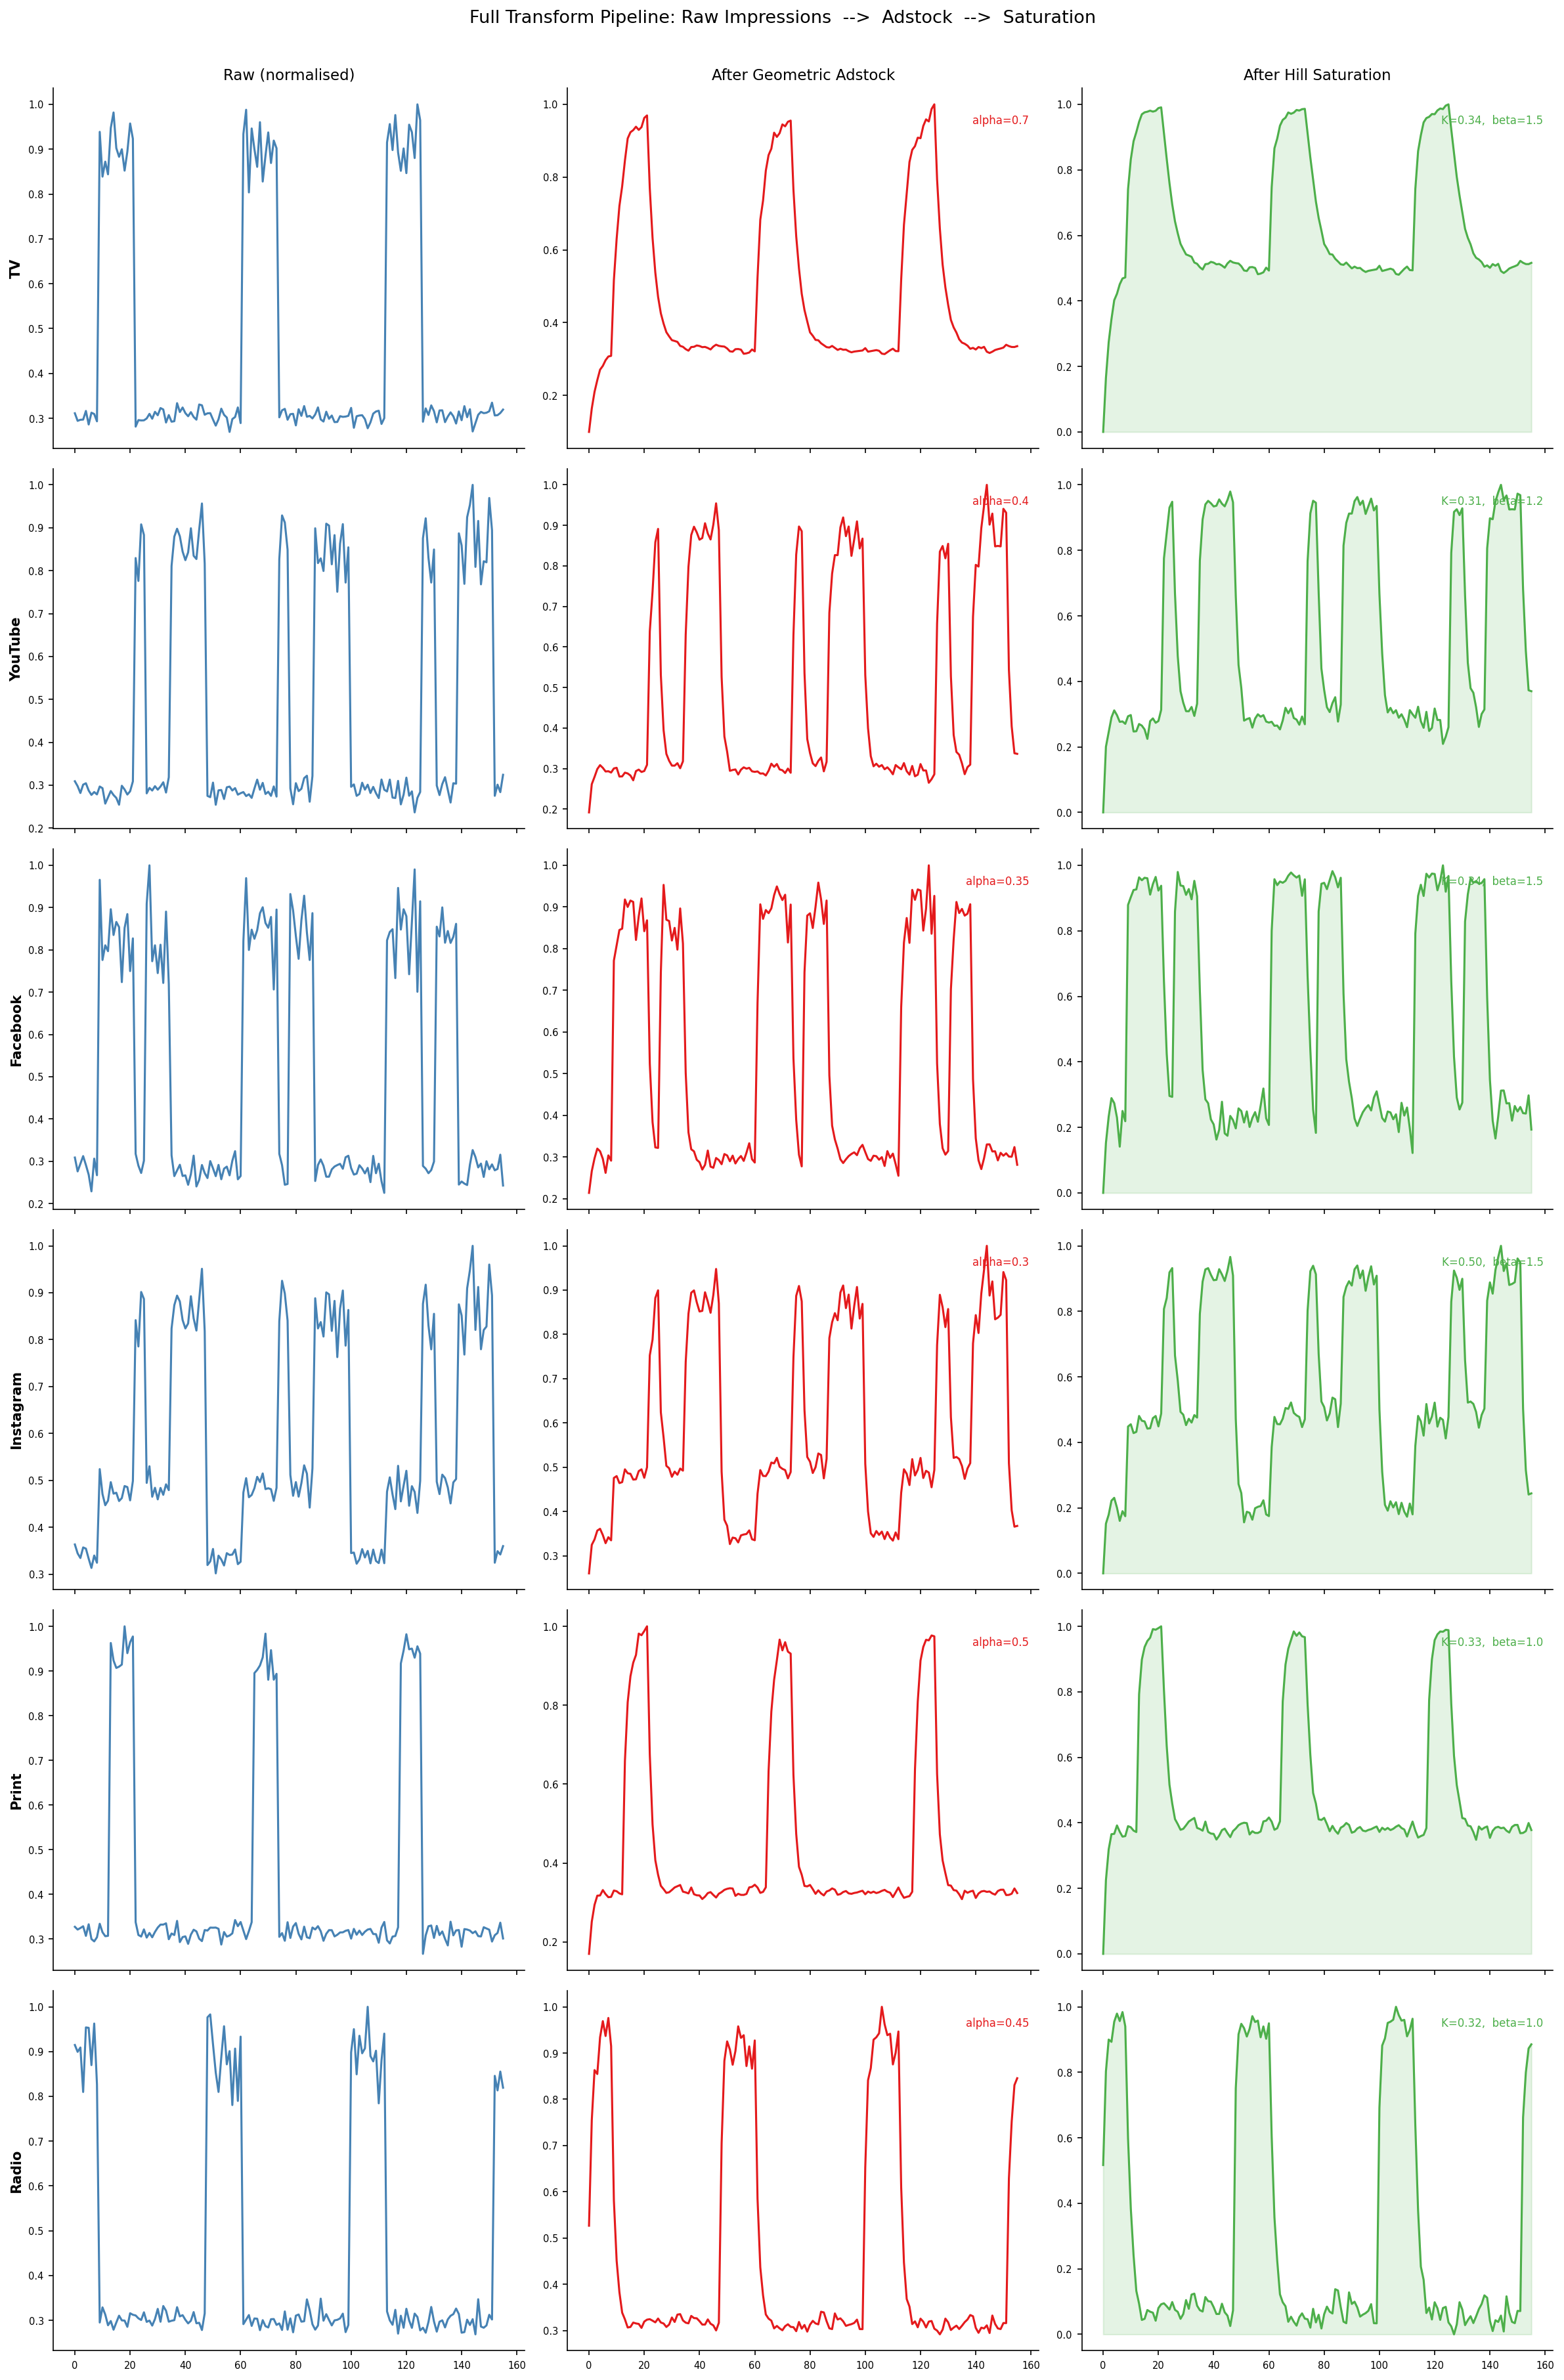


Transform Pipeline Summary
  Channel  Decay (alpha)  HL (wk)  K (median)  beta  Corr(ads,sat)      Region
       TV           0.70      1.9       0.336   1.5         0.9753 near-linear
  YouTube           0.40      0.8       0.313   1.2         0.9909 near-linear
 Facebook           0.35      0.7       0.338   1.5         0.9918 near-linear
Instagram           0.30      0.6       0.497   1.5         0.9888 near-linear
    Print           0.50      1.0       0.329   1.0         0.9893 near-linear
    Radio           0.45      0.9       0.321   1.0         0.9943 near-linear

Corr(ads,sat) close to 1.0 means saturation is near-linear at current
spend levels — channel has headroom to increase investment.


In [7]:
# ─── Channel Parameter Registry ──────────────────────────────────────────────
# Decay rates from NB02 (constrained Ridge); K set to median of adstock output
CHANNEL_PARAMS = {
    'TV_Impressions':        {'decay': 0.70, 'beta': 1.5},
    'YouTube_Impressions':   {'decay': 0.40, 'beta': 1.2},
    'Facebook_Impressions':  {'decay': 0.35, 'beta': 1.5},
    'Instagram_Impressions': {'decay': 0.30, 'beta': 1.5},
    'Print_Readership':      {'decay': 0.50, 'beta': 1.0},
    'Radio_Listenership':    {'decay': 0.45, 'beta': 1.0},
}

CH_LABELS = {
    'TV_Impressions':        'TV',
    'YouTube_Impressions':   'YouTube',
    'Facebook_Impressions':  'Facebook',
    'Instagram_Impressions': 'Instagram',
    'Print_Readership':      'Print',
    'Radio_Listenership':    'Radio',
}

n_ch  = len(CHANNEL_PARAMS)
fig, axes = plt.subplots(n_ch, 3, figsize=(16, 4 * n_ch), sharex=True)

pipeline_summary = []

for idx, (col, params) in enumerate(CHANNEL_PARAMS.items()):
    raw_vals = media_natl[col].values.astype(float)
    mx       = raw_vals.max()
    raw_norm = raw_vals / mx if mx > 0 else raw_vals

    # Step 1: Geometric Adstock
    ads_vals = geometric_adstock(raw_norm, decay=params['decay'], normalise=True)

    # Step 2: Hill Saturation — K = median of adstock series
    K        = float(np.median(ads_vals))
    sat_vals = hill_saturation(ads_vals, K=K, beta=params['beta'])
    sat_rng  = sat_vals.max() - sat_vals.min()
    sat_norm = (sat_vals - sat_vals.min()) / (sat_rng + 1e-10)

    label = CH_LABELS[col]

    # Panel 1: Raw
    axes[idx, 0].plot(raw_norm, color='steelblue', lw=1.5)
    axes[idx, 0].set_ylabel(label, fontsize=10, fontweight='bold')
    if idx == 0:
        axes[idx, 0].set_title('Raw (normalised)', fontsize=11)

    # Panel 2: Adstock
    axes[idx, 1].plot(ads_vals, color='#e41a1c', lw=1.5)
    if idx == 0:
        axes[idx, 1].set_title('After Geometric Adstock', fontsize=11)
    axes[idx, 1].text(0.98, 0.90, f"alpha={params['decay']}", ha='right',
                      transform=axes[idx, 1].transAxes, fontsize=8, color='#e41a1c')

    # Panel 3: Saturation
    axes[idx, 2].plot(sat_norm, color='#4daf4a', lw=1.5)
    axes[idx, 2].fill_between(range(len(sat_norm)), 0, sat_norm, alpha=0.15, color='#4daf4a')
    if idx == 0:
        axes[idx, 2].set_title('After Hill Saturation', fontsize=11)
    axes[idx, 2].text(0.98, 0.90, f"K={K:.2f},  beta={params['beta']}", ha='right',
                      transform=axes[idx, 2].transAxes, fontsize=8, color='#4daf4a')

    corr_as = np.corrcoef(ads_vals, sat_norm)[0, 1]
    pipeline_summary.append({
        'Channel':        label,
        'Decay (alpha)':  params['decay'],
        'HL (wk)':        round(half_life(params['decay']), 1),
        'K (median)':     round(K, 3),
        'beta':           params['beta'],
        'Corr(ads,sat)':  round(corr_as, 4),
        'Region':         'near-linear' if corr_as > 0.97 else 'non-linear',
    })

for ax in axes.flat:
    ax.tick_params(labelsize=7)

fig.suptitle('Full Transform Pipeline: Raw Impressions  -->  Adstock  -->  Saturation',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_full_transform_pipeline.png', bbox_inches='tight', dpi=150)
plt.show()

summary_df = pd.DataFrame(pipeline_summary)
print("\nTransform Pipeline Summary")
print("=" * 70)
print(summary_df.to_string(index=False))
print()
print("Corr(ads,sat) close to 1.0 means saturation is near-linear at current")
print("spend levels — channel has headroom to increase investment.")

## 7. Parameter Sensitivity Analysis

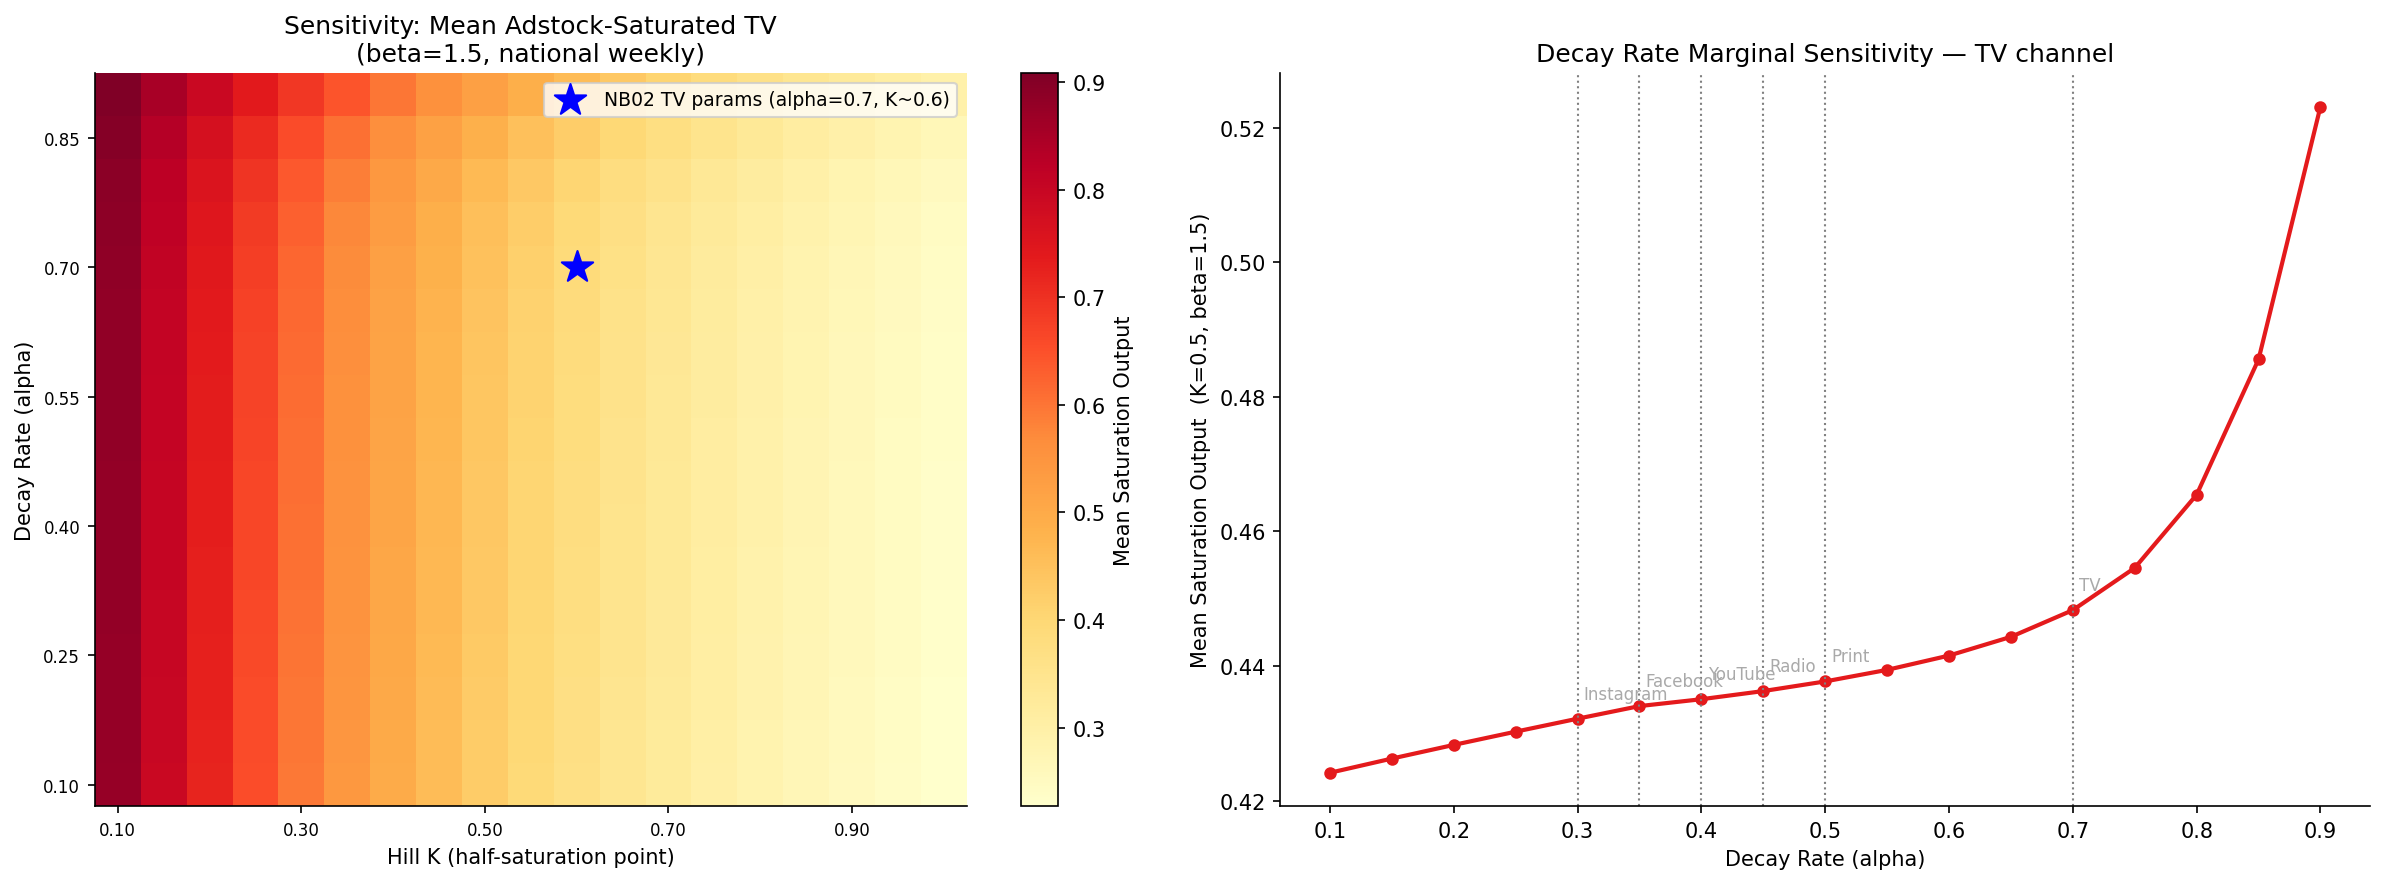


Near-linear vs Non-linear Region  (TV national, beta=1.5):
------------------------------------------------------------
   alpha      K  Corr(ads,sat)   Region
  --------------------------------------------------------
    0.30   0.30         0.9938   near-linear
    0.30   0.50         0.9973   near-linear
    0.30   0.80         0.9992   near-linear
    0.50   0.30         0.9865   near-linear
    0.50   0.50         0.9947   near-linear
    0.50   0.80         0.9985   near-linear
    0.70   0.30         0.9693   non-linear
    0.70   0.50         0.9896   near-linear
    0.70   0.80         0.9974   near-linear


In [8]:
# ─── Sensitivity Grid: Decay × K → Mean Saturation Output ────────────────────
# Use national TV as representative channel
tv_vals  = media_natl['TV_Impressions'].values.astype(float)
tv_norm  = tv_vals / tv_vals.max()

decay_grid = np.round(np.arange(0.10, 0.95, 0.05), 2)
K_grid     = np.round(np.arange(0.10, 1.05, 0.05), 2)

heatmap = np.zeros((len(decay_grid), len(K_grid)))
for i, alpha in enumerate(decay_grid):
    ads = geometric_adstock(tv_norm, alpha, normalise=True)
    for j, K in enumerate(K_grid):
        sat            = hill_saturation(ads, K=K, beta=1.5)
        heatmap[i, j]  = sat.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Heatmap ──────────────────────────────────────────────────────────────────
im = axes[0].imshow(heatmap, aspect='auto', cmap='YlOrRd', origin='lower')
x_ticks = np.arange(0, len(K_grid),     4)
y_ticks = np.arange(0, len(decay_grid), 3)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels([f'{K_grid[k]:.2f}' for k in x_ticks], fontsize=8)
axes[0].set_yticks(y_ticks)
axes[0].set_yticklabels([f'{decay_grid[d]:.2f}' for d in y_ticks], fontsize=8)
axes[0].set_xlabel('Hill K (half-saturation point)')
axes[0].set_ylabel('Decay Rate (alpha)')
axes[0].set_title('Sensitivity: Mean Adstock-Saturated TV\n(beta=1.5, national weekly)', fontsize=12)
plt.colorbar(im, ax=axes[0], label='Mean Saturation Output')

# Mark NB02 parameters
cur_i = int(np.argmin(np.abs(decay_grid - 0.70)))
cur_j = int(np.argmin(np.abs(K_grid    - 0.60)))
axes[0].scatter([cur_j], [cur_i], color='blue', s=250, marker='*',
                zorder=10, label='NB02 TV params (alpha=0.7, K~0.6)')
axes[0].legend(fontsize=9)

# ─── Decay Marginal Sensitivity ───────────────────────────────────────────────
decay_sens = []
for alpha in decay_grid:
    ads = geometric_adstock(tv_norm, alpha, normalise=True)
    sat = hill_saturation(ads, K=0.50, beta=1.5)
    decay_sens.append(sat.mean())

axes[1].plot(decay_grid, decay_sens, 'o-', color='#e41a1c', lw=2, ms=5)
for ch_name, ch_alpha in channel_decays.items():
    if any(np.isclose(decay_grid, ch_alpha)):
        idx_ch = int(np.argmin(np.abs(decay_grid - ch_alpha)))
        axes[1].axvline(ch_alpha, color='grey', ls=':', lw=1)
        axes[1].text(ch_alpha + 0.005, decay_sens[idx_ch] + 0.003,
                     ch_name, fontsize=8, color='darkgrey')
axes[1].set_xlabel('Decay Rate (alpha)')
axes[1].set_ylabel('Mean Saturation Output  (K=0.5, beta=1.5)')
axes[1].set_title('Decay Rate Marginal Sensitivity — TV channel', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_sensitivity_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# ─── Linearity Assessment ─────────────────────────────────────────────────────
print("\nNear-linear vs Non-linear Region  (TV national, beta=1.5):")
print("-" * 60)
print(f"  {'alpha':>6} {'K':>6} {'Corr(ads,sat)':>14}   Region")
print("  " + "-" * 56)
for alpha in [0.30, 0.50, 0.70]:
    ads = geometric_adstock(tv_norm, alpha, normalise=True)
    for K in [0.30, 0.50, 0.80]:
        sat    = hill_saturation(ads, K=K, beta=1.5)
        corr   = np.corrcoef(ads, sat)[0, 1]
        region = 'near-linear' if corr > 0.97 else 'non-linear'
        print(f"  {alpha:>6.2f} {K:>6.2f} {corr:>14.4f}   {region}")

## 8. Save Transform Figures

In [9]:
# ─── Figure Registry & Verification ─────────────────────────────────────────
figure_registry = [
    ('03_geometric_adstock_impulse.png', 'Impulse response + half-life bar chart'),
    ('03_weibull_adstock.png',           'Weibull impulse responses + PDF kernel weights'),
    ('03_geo_vs_weibull_tv.png',         '3-panel: raw TV, geometric, Weibull on real data'),
    ('03_hill_saturation.png',           'Hill K/beta sensitivity + marginal returns grid'),
    ('03_saturation_comparison.png',     'Logistic vs Neg-Exp vs Hill comparison'),
    ('03_full_transform_pipeline.png',   '6-channel end-to-end pipeline'),
    ('03_sensitivity_analysis.png',      'Decay x K heatmap + decay marginal sensitivity'),
]

print("Saved Figures")
print("=" * 75)
for fn, desc in figure_registry:
    path    = os.path.join(OUTPUT_DIR, fn)
    exists  = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024 if exists else 0
    mark    = '[OK]' if exists else '[!!]'
    print(f"  {mark} {fn:<46}  {size_kb:>6.0f} KB")
    print(f"       {desc}")

print()
print("=" * 75)
print("Transform Library — Function Reference")
print("=" * 75)
print()
print("Adstock functions")
print("  geometric_adstock(x, decay, normalise=True)")
print("    -> stock[t] = x[t] + decay * stock[t-1]")
print("    -> half_life(alpha) = log(0.5) / log(alpha)")
print()
print("  weibull_adstock(x, shape, scale, maxlag=20, normalise=True)")
print("    -> k < 1: fast decay  |  k=1: geometric  |  k > 1: delayed peak")
print()
print("Saturation functions")
print("  hill_saturation(x, K, beta)")
print("    -> f(x) = x^beta / (K^beta + x^beta)  [industry standard]")
print()
print("  logistic_saturation(x, lam, mu)")
print("    -> f(x) = 1 / (1 + exp(-lam*(x-mu)))  [symmetric S-curve]")
print()
print("  neg_exp_saturation(x, a)")
print("    -> f(x) = 1 - exp(-a*x)  [concave only]")
print()
print("  marginal_hill(x, K, beta)")
print("    -> analytic dS/dx for spend allocation")
print()
print("Recommendation: Hill saturation + geometric adstock for NB04-NB06.")
print("  PyMC-Marketing uses the same Hill function natively.")
print("  Meridian uses a custom Hill formulation — same concept.")
print("  Key decision per Bayesian MMM (NB04): put priors directly on K and beta.")

Saved Figures
  [OK] 03_geometric_adstock_impulse.png                   129 KB
       Impulse response + half-life bar chart
  [OK] 03_weibull_adstock.png                             128 KB
       Weibull impulse responses + PDF kernel weights
  [OK] 03_geo_vs_weibull_tv.png                           193 KB
       3-panel: raw TV, geometric, Weibull on real data
  [OK] 03_hill_saturation.png                             261 KB
       Hill K/beta sensitivity + marginal returns grid
  [OK] 03_saturation_comparison.png                       173 KB
       Logistic vs Neg-Exp vs Hill comparison
  [OK] 03_full_transform_pipeline.png                     836 KB
       6-channel end-to-end pipeline
  [OK] 03_sensitivity_analysis.png                        127 KB
       Decay x K heatmap + decay marginal sensitivity

Transform Library — Function Reference

Adstock functions
  geometric_adstock(x, decay, normalise=True)
    -> stock[t] = x[t] + decay * stock[t-1]
    -> half_life(alpha) = log(0.5)

---

## Key Insights from Adstock & Saturation Transform Analysis

### 1. Geometric Adstock — Channel Half-Lives
| Channel   | Decay (α) | Half-Life (wk) | Effect persists to week |
|-----------|-----------|----------------|------------------------|
| TV        | 0.70      | 1.9            | 13                     |
| Print     | 0.50      | 1.0            | 7                      |
| YouTube   | 0.40      | 0.8            | 6                      |
| Radio     | 0.45      | 0.9            | 6                      |
| Facebook  | 0.35      | 0.7            | 5                      |
| Instagram | 0.30      | 0.6            | 4                      |

**TV has the longest carryover** (α = 0.70) — each GRP continues generating
awareness for ~13 weeks, justifying its high partial R² in NB02. Instagram and
Facebook decay fastest; their impressions must be treated mostly as in-week stimuli.

### 2. Geometric vs. Weibull Adstock on Real Data
- Pearson correlation on national weekly TV: **r = 0.9764** (MAE ≈ 7.5%)
- Both transforms capture very similar information on weekly FMCG data
- **Weibull advantage**: delayed-peak shape parameter k > 1 models initial
  brand-awareness build-up before sales lift — relevant for TV/OOH campaigns
- **Recommendation**: Use geometric for classical and Bayesian MMM (NB02–NB04)
  for parsimony; Weibull as a robustness check in NB06 (Meridian)

### 3. Hill Saturation Parameters
- **K** (half-saturation constant) = the spend/impression level at which a
  channel reaches 50% of its maximum saturation response
  - K derived from median adstock output: TV K ≈ 0.336, Instagram K ≈ 0.497
  - Higher K → channel is further from saturation → more room to invest
- **β** (Hill coefficient) controls S-curve shape:
  - β < 1: pure diminishing returns (suitable for Radio, Print)
  - β = 1: Michaelis-Menten (gentle S-shape, TV baseline)
  - β > 1: steeper inflection (TV awareness build, Facebook awareness campaigns)

### 4. All Channels Operate in the Near-Linear Saturation Regime
All 6 media channels show saturation Corr(adstock, saturated) > **0.97** at
current India spend levels:

| Channel   | Corr(ads, sat) | Saturation Region |
|-----------|---------------|-------------------|
| TV        | 0.9753        | near-linear       |
| YouTube   | 0.9909        | near-linear       |
| Facebook  | 0.9918        | near-linear       |
| Instagram | 0.9888        | near-linear       |
| Print     | 0.9893        | near-linear       |
| Radio     | 0.9943        | near-linear       |

**Implication**: Every channel has headroom before it hits hard saturation.
Marginal returns are still relatively healthy (steep part of the Hill curve).
This supports budget reallocation experiments (NB09) rather than pure cuts.

### 5. Sensitivity Analysis — When Does Saturation Bite?
- TV (α = 0.70) enters the non-linear regime only when K falls below 0.40
  (i.e., median adstock exceeds 40% of the saturation ceiling)
- At current K ≈ 0.34, TV is *just* entering the S-curve inflection region
- Low-decay channels (Instagram, Facebook) remain near-linear even at K = 0.30
  because short half-life limits cumulative adstock build-up

### 6. Saturation Function Selection
| Function   | Shape        | Key Property            | Best Use Case                |
|------------|-------------|------------------------|------------------------------|
| Hill       | Flexible S  | K and β interpretable  | All media in this project ✓  |
| Logistic   | Symmetric S | Inflection at μ        | Threshold channels           |
| Neg-Exp    | Concave     | No S-curve inflection  | Tactical digital / SEM       |

**Hill saturation is selected** — identical form used by PyMC-Marketing (NB04)
and Google Meridian (NB06), enabling direct model comparisons.

### 7. Implications for Downstream Modelling
- **NB04 (Bayesian MMM)**: Place half-normal or lognormal priors on K (> 0); 
  Beta(2, 4) prior on β to favour moderate S-shape; geometric adstock decay
  rates serve as prior means
- **NB06 (Meridian)**: Meridian's `hill_saturation` uses the same K/β form —
  initialise with median-adstock K values derived here
- **NB09 (Budget Optimisation)**: Use `marginal_hill(x, K, beta)` to compute
  marginal ROI curves that drive budget reallocation algorithm
